# 📊 Tratamento e Preparação de Dados
## Dataset: *Default of Credit Card Clients*
---
**Disciplina:** Tópicos em Engenharia de Computação  
**Dataset:** Default of Credit Card Clients – UCI Machine Learning Repository  
**Objetivo:** Limpeza, organização, transformação, engenharia de atributos e visualização gráfica da base de dados de inadimplência de clientes de cartão de crédito.

> **Fonte:** Yeh, I. C., & Lien, C. H. (2009). *The comparisons of data mining techniques for the predictive accuracy of probability of default of credit card clients.* Expert Systems with Applications.


---
## 1. Importação das Bibliotecas Necessárias
Carregamento das principais bibliotecas utilizadas no processo de tratamento, análise e visualização dos dados.


In [ ]:
# Importação das bibliotecas necessárias
import pandas as pd                        # Manipulação e análise de dados tabulares
import numpy as np                         # Operações numéricas e matriciais
import matplotlib.pyplot as plt            # Base para renderização dos gráficos
import matplotlib.ticker as mticker        # Formatação de eixos
import seaborn as sns                      # Visualizações estatísticas de alto nível
import warnings

# ── Configurações gerais ──────────────────────────────────────
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
warnings.filterwarnings('ignore')

# ── Estilo global dos gráficos ────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'

print("Bibliotecas importadas com sucesso!")
print(f"Pandas   versão: {pd.__version__}")
print(f"NumPy    versão: {np.__version__}")
print(f"Seaborn  versão: {sns.__version__}")


Bibliotecas importadas com sucesso!
   • Pandas   versão: 3.0.2
   • NumPy    versão: 2.4.4
   • Seaborn  versão: 0.13.2


In [2]:
import subprocess
import sys

def export_requirements():
    try: 
        resultado = subprocess.run([sys.executable, '-m', 'pip', 'freeze'],
                                capture_output=True, 
                                text=True,
                                check=True)
        with open('requirements.txt', 'w') as f:
            f.write(resultado.stdout)
        print("Arquivo requirements.txt exportado com sucesso!")
    except subprocess.CalledProcessError as e:
        print("Erro ao exportar requirements.txt:", e)
export_requirements()

Arquivo requirements.txt exportado com sucesso!


---
## 2. Carregamento do Dataset
O dataset é carregado diretamente do repositório UCI via URL pública.  
A primeira linha do arquivo Excel contém metadados e é ignorada (`header=1`).


In [ ]:
URL = (
    "https://archive.ics.uci.edu/ml/machine-learning-databases/"
    "00350/default%20of%20credit%20card%20clients.xls"
)

try:
    df_raw = pd.read_excel(URL, header=1)
    print(f"Dataset carregado com sucesso!")
    print(f"Linhas : {df_raw.shape[0]:,}")
    print(f"Colunas: {df_raw.shape[1]}")
except Exception as e:
    print(f"Falha no download ({e}).")
    print("   Tente: df_raw = pd.read_excel('default_of_credit_card_clients.xls', header=1)")


Dataset carregado com sucesso!
   • Linhas : 30,000
   • Colunas: 25


---
## 3. Visualização Inicial da Base de Dados
Inspeção das primeiras e últimas linhas para compreender a estrutura e o conteúdo bruto do dataset.


In [4]:
print("Primeiras 5 linhas:")
display(df_raw.head())


Primeiras 5 linhas:


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [5]:
print("Últimas 5 linhas:")
display(df_raw.tail())


Últimas 5 linhas:


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
29995,29996,220000,1,3,1,39,0,0,0,0,0,0,188948,192815,208365,88004,31237,15980,8500,20000,5003,3047,5000,1000,0
29996,29997,150000,1,3,2,43,-1,-1,-1,-1,0,0,1683,1828,3502,8979,5190,0,1837,3526,8998,129,0,0,0
29997,29998,30000,1,2,2,37,4,3,2,-1,0,0,3565,3356,2758,20878,20582,19357,0,0,22000,4200,2000,3100,1
29998,29999,80000,1,3,1,41,1,-1,0,0,0,-1,-1645,78379,76304,52774,11855,48944,85900,3409,1178,1926,52964,1804,1
29999,30000,50000,1,2,1,46,0,0,0,0,0,0,47929,48905,49764,36535,32428,15313,2078,1800,1430,1000,1000,1000,1


---
## 4. Verificação da Estrutura do Dataset
Análise das dimensões, tipos de dados e nomes das colunas para identificar inconsistências antes da limpeza.


In [6]:
# 4.1 Dimensões
linhas, colunas = df_raw.shape
print(f"Dimensões:  {linhas:,} registros  ×  {colunas} variáveis")


Dimensões:  30,000 registros  ×  25 variáveis


In [7]:
# 4.2 Tipos de dados e valores não-nulos
print("Informações gerais do dataset:\n")
df_raw.info()


Informações gerais do dataset:

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   ID                          30000 non-null  int64
 1   LIMIT_BAL                   30000 non-null  int64
 2   SEX                         30000 non-null  int64
 3   EDUCATION                   30000 non-null  int64
 4   MARRIAGE                    30000 non-null  int64
 5   AGE                         30000 non-null  int64
 6   PAY_0                       30000 non-null  int64
 7   PAY_2                       30000 non-null  int64
 8   PAY_3                       30000 non-null  int64
 9   PAY_4                       30000 non-null  int64
 10  PAY_5                       30000 non-null  int64
 11  PAY_6                       30000 non-null  int64
 12  BILL_AMT1                   30000 non-null  int64
 13  BILL_AMT2                   30000 non-nu

In [8]:
# 4.3 Nomes originais das colunas
print("Colunas originais:")
for i, col in enumerate(df_raw.columns, 1):
    print(f"   {i:>2}. {col}")


Colunas originais:
    1. ID
    2. LIMIT_BAL
    3. SEX
    4. EDUCATION
    5. MARRIAGE
    6. AGE
    7. PAY_0
    8. PAY_2
    9. PAY_3
   10. PAY_4
   11. PAY_5
   12. PAY_6
   13. BILL_AMT1
   14. BILL_AMT2
   15. BILL_AMT3
   16. BILL_AMT4
   17. BILL_AMT5
   18. BILL_AMT6
   19. PAY_AMT1
   20. PAY_AMT2
   21. PAY_AMT3
   22. PAY_AMT4
   23. PAY_AMT5
   24. PAY_AMT6
   25. default payment next month


In [9]:
# 4.4 Estatísticas descritivas
print("Estatísticas descritivas:\n")
display(df_raw.describe())


Estatísticas descritivas:



,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
count,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00
mean,15000.50,167484.32,1.60,1.85,1.55,35.49,-0.02,-0.13,-0.17,-0.22,-0.27,-0.29,51223.33,49179.08,47013.15,43262.95,40311.40,38871.76,5663.58,5921.16,5225.68,4826.08,4799.39,5215.50,0.22
std,8660.40,129747.66,0.49,0.79,0.52,9.22,1.12,1.20,1.20,1.17,1.13,1.15,73635.86,71173.77,69349.39,64332.86,60797.16,59554.11,16563.28,23040.87,17606.96,15666.16,15278.31,17777.47,0.42
min,1.00,10000.00,1.00,0.00,0.00,21.00,-2.00,-2.00,-2.00,-2.00,-2.00,-2.00,-165580.00,-69777.00,-157264.00,-170000.00,-81334.00,-339603.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,7500.75,50000.00,1.00,1.00,1.00,28.00,-1.00,-1.00,-1.00,-1.00,-1.00,-1.00,3558.75,2984.75,2666.25,2326.75,1763.00,1256.00,1000.00,833.00,390.00,296.00,252.50,117.75,0.00
50%,15000.50,140000.00,2.00,2.00,2.00,34.00,0.00,0.00,0.00,0.00,0.00,0.00,22381.50,21200.00,20088.50,19052.00,18104.50,17071.00,2100.00,2009.00,1800.00,1500.00,1500.00,1500.00,0.00
75%,22500.25,240000.00,2.00,2.00,2.00,41.00,0.00,0.00,0.00,0.00,0.00,0.00,67091.00,64006.25,60164.75,54506.00,50190.50,49198.25,5006.00,5000.00,4505.00,4013.25,4031.50,4000.00,0.00
max,30000.00,1000000.00,2.00,6.00,3.00,79.00,8.00,8.00,8.00,8.00,8.00,8.00,964511.00,983931.00,1664089.00,891586.00,927171.00,961664.00,873552.00,1684259.00,896040.00,621000.00,426529.00,528666.00,1.00


### 📈 Gráfico 4.1 — Mapa de Calor: Valores Ausentes por Coluna
Visualização da presença ou ausência de valores em cada variável do dataset bruto.


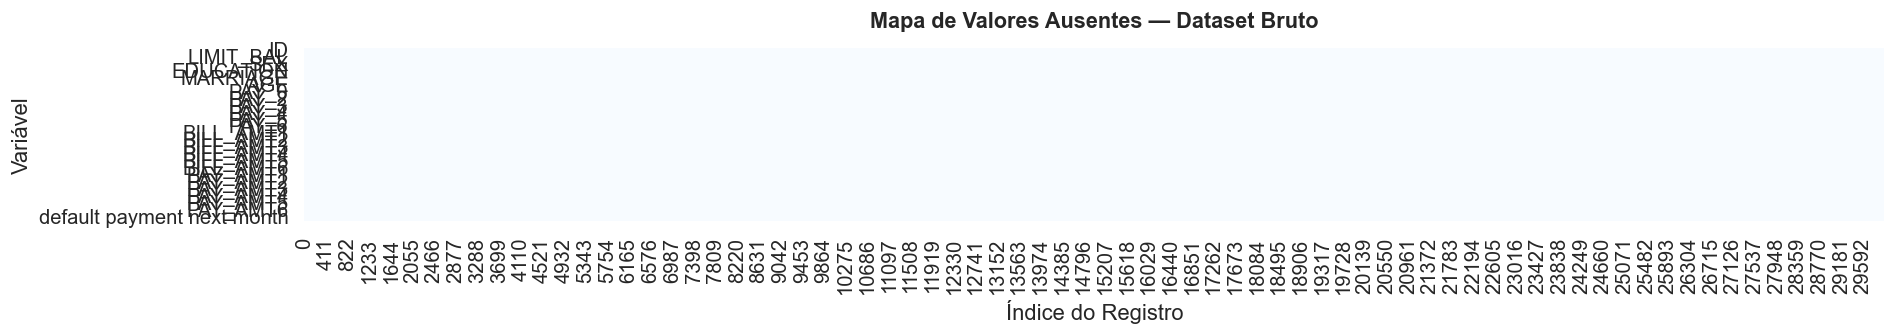


Total de valores nulos no dataset bruto: 0


In [10]:
# Heatmap de valores nulos no dataset original
fig, ax = plt.subplots(figsize=(16, 3))

sns.heatmap(
    df_raw.isnull().transpose(),
    cbar=False,
    cmap='Blues',
    yticklabels=True,
    ax=ax
)

ax.set_title('Mapa de Valores Ausentes — Dataset Bruto', pad=12)
ax.set_xlabel('Índice do Registro')
ax.set_ylabel('Variável')
plt.tight_layout()
plt.show()

# Confirmação textual
total_nulos = df_raw.isnull().sum().sum()
print(f"\nTotal de valores nulos no dataset bruto: {total_nulos}")


---
## 5. Renomeação e Padronização das Colunas
Tradução dos nomes para o português, remoção de espaços e padronização em letras minúsculas.


In [11]:
df = df_raw.copy()

mapa_colunas = {
    'ID'                        : 'id',
    'LIMIT_BAL'                 : 'limite_credito',
    'SEX'                       : 'sexo',
    'EDUCATION'                 : 'escolaridade',
    'MARRIAGE'                  : 'estado_civil',
    'AGE'                       : 'idade',
    'PAY_0'                     : 'status_pag_set',
    'PAY_2'                     : 'status_pag_ago',
    'PAY_3'                     : 'status_pag_jul',
    'PAY_4'                     : 'status_pag_jun',
    'PAY_5'                     : 'status_pag_mai',
    'PAY_6'                     : 'status_pag_abr',
    'BILL_AMT1'                 : 'fatura_set',
    'BILL_AMT2'                 : 'fatura_ago',
    'BILL_AMT3'                 : 'fatura_jul',
    'BILL_AMT4'                 : 'fatura_jun',
    'BILL_AMT5'                 : 'fatura_mai',
    'BILL_AMT6'                 : 'fatura_abr',
    'PAY_AMT1'                  : 'pagamento_set',
    'PAY_AMT2'                  : 'pagamento_ago',
    'PAY_AMT3'                  : 'pagamento_jul',
    'PAY_AMT4'                  : 'pagamento_jun',
    'PAY_AMT5'                  : 'pagamento_mai',
    'PAY_AMT6'                  : 'pagamento_abr',
    'default payment next month': 'inadimplente',
}

df.rename(columns=mapa_colunas, inplace=True)

print("Colunas renomeadas com sucesso!")
print("\nNovos nomes das colunas:")
for i, col in enumerate(df.columns, 1):
    print(f"   {i:>2}. {col}")


Colunas renomeadas com sucesso!

Novos nomes das colunas:
    1. id
    2. limite_credito
    3. sexo
    4. escolaridade
    5. estado_civil
    6. idade
    7. status_pag_set
    8. status_pag_ago
    9. status_pag_jul
   10. status_pag_jun
   11. status_pag_mai
   12. status_pag_abr
   13. fatura_set
   14. fatura_ago
   15. fatura_jul
   16. fatura_jun
   17. fatura_mai
   18. fatura_abr
   19. pagamento_set
   20. pagamento_ago
   21. pagamento_jul
   22. pagamento_jun
   23. pagamento_mai
   24. pagamento_abr
   25. inadimplente


---
## 6. Tratamento de Dados
### 6.1 Verificação de Valores Nulos


In [12]:
nulos = df.isnull().sum()
pct_nulos = (nulos / len(df) * 100).round(2)
resumo_nulos = pd.DataFrame({'Nulos': nulos, 'Percentual': pct_nulos}).query('Nulos > 0')

if resumo_nulos.empty:
    print("Nenhum valor nulo encontrado no dataset.")
else:
    print("Colunas com valores nulos:")
    display(resumo_nulos)


Nenhum valor nulo encontrado no dataset.


### 6.2 Identificação e Remoção de Duplicatas


In [13]:
n_duplicados = df.duplicated().sum()
print(f"Registros duplicados encontrados: {n_duplicados}")

if n_duplicados > 0:
    df.drop_duplicates(inplace=True)
    df.reset_index(drop=True, inplace=True)
    print(f"Duplicatas removidas. Registros restantes: {len(df):,}")
else:
    print("Nenhuma duplicata encontrada.")


Registros duplicados encontrados: 0
Nenhuma duplicata encontrada.


### 6.3 Remoção da Coluna de ID


In [ ]:
if 'id' in df.columns:
    df.drop(columns=['id'], inplace=True)
    print("Coluna 'id' removida.")
print(f"Dimensões após remoção: {df.shape}")


Coluna 'id' removida.
   • Dimensões após remoção: (30000, 24)


### 6.4 Identificação de Categorias Inconsistentes


In [15]:
categoricas = ['sexo', 'escolaridade', 'estado_civil']
for col in categoricas:
    contagem = df[col].value_counts().sort_index()
    print(f"\n '{col}' — valores únicos: {df[col].nunique()}")
    print(contagem.to_string())



 'sexo' — valores únicos: 2
sexo
1    11888
2    18112

 'escolaridade' — valores únicos: 7
escolaridade
0       14
1    10585
2    14030
3     4917
4      123
5      280
6       51

 'estado_civil' — valores únicos: 4
estado_civil
0       54
1    13659
2    15964
3      323


### 📈 Gráfico 6.1 — Distribuição das Variáveis Categóricas (Valores Brutos)
Frequência de cada código numérico antes da conversão para rótulos descritivos.


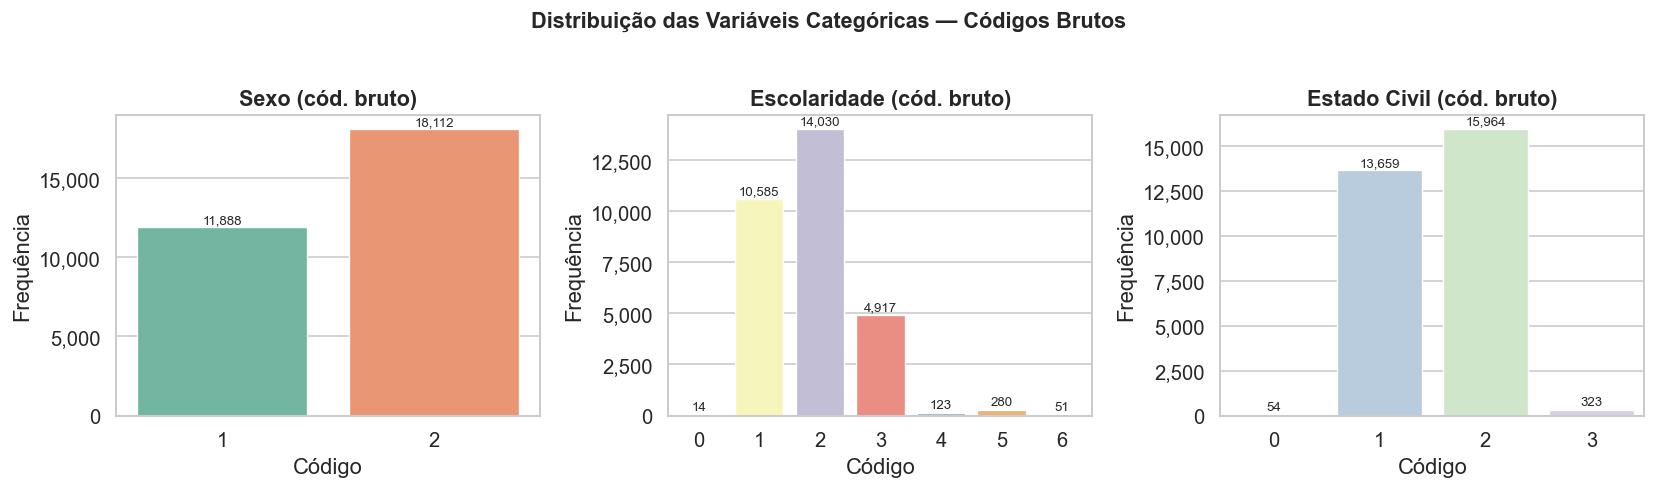

In [16]:
# Distribuição das variáveis categóricas antes do mapeamento
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
cats_info = [
    ('sexo',         'Sexo (cód. bruto)',        sns.color_palette('Set2')),
    ('escolaridade', 'Escolaridade (cód. bruto)', sns.color_palette('Set3')),
    ('estado_civil', 'Estado Civil (cód. bruto)', sns.color_palette('Pastel1')),
]

for ax, (col, titulo, pal) in zip(axes, cats_info):
    ordem = sorted(df[col].unique())
    contagem = df[col].value_counts().reindex(ordem).fillna(0)
    sns.barplot(x=contagem.index.astype(str), y=contagem.values,
                palette=pal, ax=ax, edgecolor='white', linewidth=0.8)
    ax.set_title(titulo)
    ax.set_xlabel('Código')
    ax.set_ylabel('Frequência')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    for bar in ax.patches:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 80,
                f'{int(bar.get_height()):,}',
                ha='center', va='bottom', fontsize=8)

plt.suptitle('Distribuição das Variáveis Categóricas — Códigos Brutos', y=1.02, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### 6.5 Ajuste de Tipos de Dados


In [17]:
df['inadimplente'] = df['inadimplente'].astype(int)
print("Tipos de dados após ajuste:")
print(df.dtypes.to_string())


Tipos de dados após ajuste:
limite_credito    int64
sexo              int64
escolaridade      int64
estado_civil      int64
idade             int64
status_pag_set    int64
status_pag_ago    int64
status_pag_jul    int64
status_pag_jun    int64
status_pag_mai    int64
status_pag_abr    int64
fatura_set        int64
fatura_ago        int64
fatura_jul        int64
fatura_jun        int64
fatura_mai        int64
fatura_abr        int64
pagamento_set     int64
pagamento_ago     int64
pagamento_jul     int64
pagamento_jun     int64
pagamento_mai     int64
pagamento_abr     int64
inadimplente      int64


---
## 7. Tratamento Específico das Variáveis Categóricas
Substituição dos códigos numéricos por rótulos descritivos.


In [18]:
# ── 7.1 SEXO ─────────────────────────────────────────────────
mapa_sexo = {1: 'Masculino', 2: 'Feminino'}
df['sexo'] = df['sexo'].map(mapa_sexo)
print("✅ 'sexo' transformado:"); print(df['sexo'].value_counts().to_string())


✅ 'sexo' transformado:
sexo
Feminino     18112
Masculino    11888


In [19]:
# ── 7.2 ESCOLARIDADE ─────────────────────────────────────────
mapa_escolaridade = {0:'Outros', 1:'Pós-graduação', 2:'Graduação',
                     3:'Ensino Médio', 4:'Outros', 5:'Outros', 6:'Outros'}
df['escolaridade'] = df['escolaridade'].map(mapa_escolaridade)
print("'escolaridade' transformada:"); print(df['escolaridade'].value_counts().to_string())


'escolaridade' transformada:
escolaridade
Graduação        14030
Pós-graduação    10585
Ensino Médio      4917
Outros             468


In [20]:
# ── 7.3 ESTADO CIVIL ─────────────────────────────────────────
mapa_estado_civil = {0:'Outros', 1:'Casado', 2:'Solteiro', 3:'Outros'}
df['estado_civil'] = df['estado_civil'].map(mapa_estado_civil)
print("✅ 'estado_civil' transformado:"); print(df['estado_civil'].value_counts().to_string())


✅ 'estado_civil' transformado:
estado_civil
Solteiro    15964
Casado      13659
Outros        377


### 📈 Gráfico 7.1 — Variáveis Categóricas após Mapeamento
Distribuição das categorias com rótulos descritivos e segmentação por inadimplência.


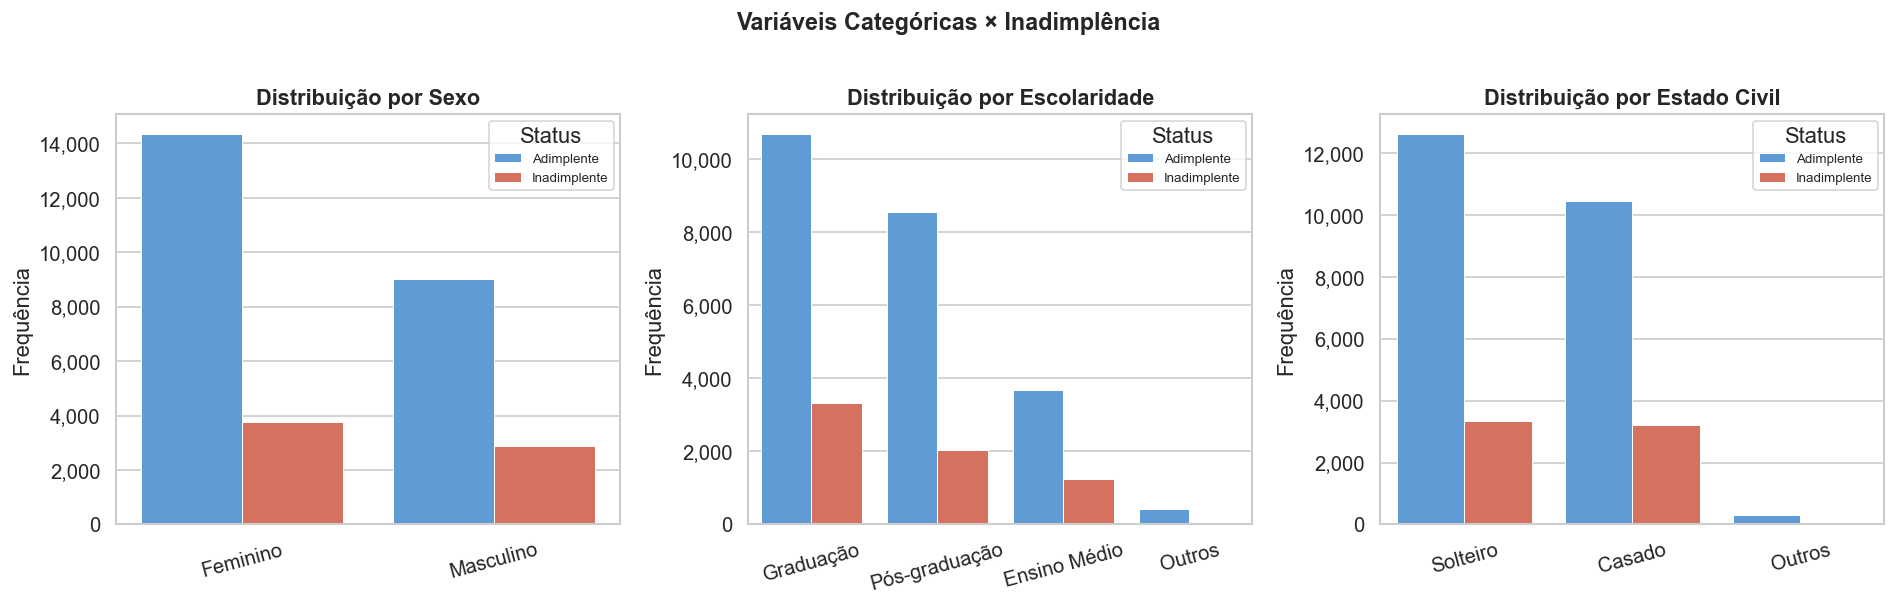

In [21]:
# Paleta para inadimplência: 0=adimplente, 1=inadimplente
paleta_alvo = {0: '#4C9BE8', 1: '#E8634C'}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
vars_cat = [
    ('sexo',         'Distribuição por Sexo'),
    ('escolaridade', 'Distribuição por Escolaridade'),
    ('estado_civil', 'Distribuição por Estado Civil'),
]

for ax, (col, titulo) in zip(axes, vars_cat):
    # Ordena categorias por frequência total
    ordem = df[col].value_counts().index.tolist()
    sns.countplot(data=df, x=col, hue='inadimplente', order=ordem,
                  palette=paleta_alvo, ax=ax, edgecolor='white', linewidth=0.6)
    ax.set_title(titulo)
    ax.set_xlabel('')
    ax.set_ylabel('Frequência')
    ax.tick_params(axis='x', rotation=15)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles, ['Adimplente', 'Inadimplente'], title='Status', fontsize=8)

plt.suptitle('Variáveis Categóricas × Inadimplência', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


### 📈 Gráfico 7.2 — Limite de Crédito por Escolaridade e Sexo
Boxplot comparativo do limite de crédito entre os grupos demográficos.


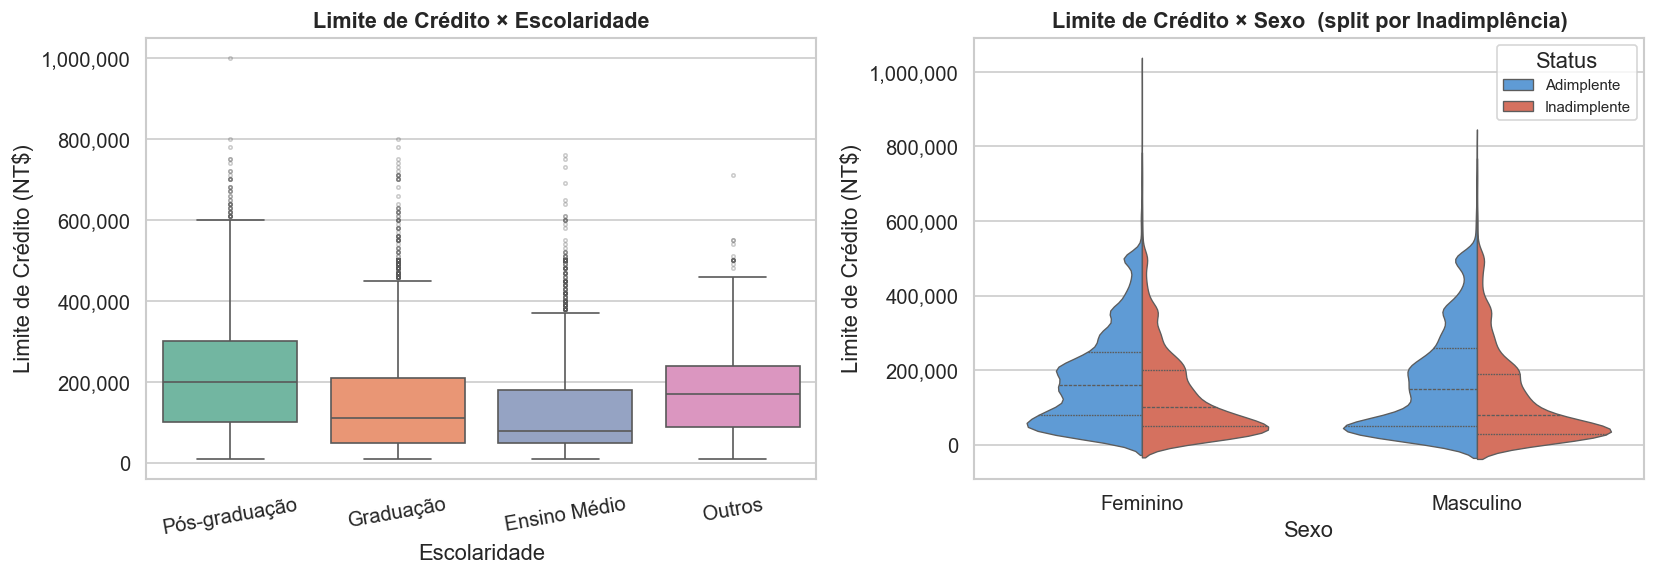

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot: limite de crédito × escolaridade
ordem_escol = ['Pós-graduação', 'Graduação', 'Ensino Médio', 'Outros']
sns.boxplot(data=df, x='escolaridade', y='limite_credito', order=ordem_escol,
            palette='Set2', ax=axes[0], flierprops=dict(marker='o', markersize=2, alpha=0.3))
axes[0].set_title('Limite de Crédito × Escolaridade')
axes[0].set_xlabel('Escolaridade')
axes[0].set_ylabel('Limite de Crédito (NT$)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[0].tick_params(axis='x', rotation=10)

# Violinplot: limite de crédito × sexo
sns.violinplot(data=df, x='sexo', y='limite_credito', hue='inadimplente',
               palette=paleta_alvo, split=True, ax=axes[1], inner='quart', linewidth=0.8)
axes[1].set_title('Limite de Crédito × Sexo  (split por Inadimplência)')
axes[1].set_xlabel('Sexo')
axes[1].set_ylabel('Limite de Crédito (NT$)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
handles2, labels2 = axes[1].get_legend_handles_labels()
axes[1].legend(handles2, ['Adimplente', 'Inadimplente'], title='Status', fontsize=9)

plt.tight_layout()
plt.show()


---
## 8. Engenharia de Atributos (*Feature Engineering*)
Criação de novas variáveis derivadas para enriquecer a análise e o poder preditivo dos modelos.


In [23]:
# Grupos de colunas de referência
cols_fatura    = ['fatura_set','fatura_ago','fatura_jul','fatura_jun','fatura_mai','fatura_abr']
cols_pagamento = ['pagamento_set','pagamento_ago','pagamento_jul','pagamento_jun','pagamento_mai','pagamento_abr']
cols_status    = ['status_pag_set','status_pag_ago','status_pag_jul','status_pag_jun','status_pag_mai','status_pag_abr']
print("Grupos de colunas definidos.")


Grupos de colunas definidos.


In [24]:
# 8.1 Média das faturas (últimos 6 meses)
df['media_fatura'] = df[cols_fatura].mean(axis=1).round(2)

# 8.2 Média dos pagamentos (últimos 6 meses)
df['media_pagamento'] = df[cols_pagamento].mean(axis=1).round(2)

# 8.3 Taxa de utilização do crédito
df['taxa_utilizacao'] = np.where(
    df['limite_credito'] > 0,
    (df['media_fatura'] / df['limite_credito']).round(4), 0
).clip(max=1.0) if False else np.clip(
    np.where(df['limite_credito'] > 0,
             df['media_fatura'] / df['limite_credito'], 0), 0, 1.0
)
df['taxa_utilizacao'] = df['taxa_utilizacao'].round(4)

# 8.4 Quantidade de meses com atraso
df['qtd_atrasos'] = (df[cols_status] >= 1).sum(axis=1)

# 8.5 Faixa etária
bins   = [0, 25, 35, 45, 55, 100]
labels = ['Até 25', '26–35', '36–45', '46–55', 'Acima de 55']
df['faixa_etaria'] = pd.cut(df['idade'], bins=bins, labels=labels, right=True)

# 8.6 Perfil de risco
def classificar_risco(row):
    if row['taxa_utilizacao'] >= 0.8 or row['qtd_atrasos'] >= 3:
        return 'Alto'
    elif row['taxa_utilizacao'] >= 0.5 or row['qtd_atrasos'] >= 1:
        return 'Médio'
    return 'Baixo'

df['perfil_risco'] = df.apply(classificar_risco, axis=1)

print("Todos os atributos de engenharia criados!")
novos = ['media_fatura','media_pagamento','taxa_utilizacao','qtd_atrasos','faixa_etaria','perfil_risco']
for a in novos:
    print(f"   ✔ {a:<22} | tipo: {str(df[a].dtype):<10} | nulos: {df[a].isnull().sum()}")


Todos os atributos de engenharia criados!
   ✔ media_fatura           | tipo: float64    | nulos: 0
   ✔ media_pagamento        | tipo: float64    | nulos: 0
   ✔ taxa_utilizacao        | tipo: float64    | nulos: 0
   ✔ qtd_atrasos            | tipo: int64      | nulos: 0
   ✔ faixa_etaria           | tipo: category   | nulos: 0
   ✔ perfil_risco           | tipo: str        | nulos: 0


### 📈 Gráfico 8.1 — Distribuição de Idade e Faixa Etária
Histograma da idade dos clientes com curva de densidade e contagem por faixa etária.


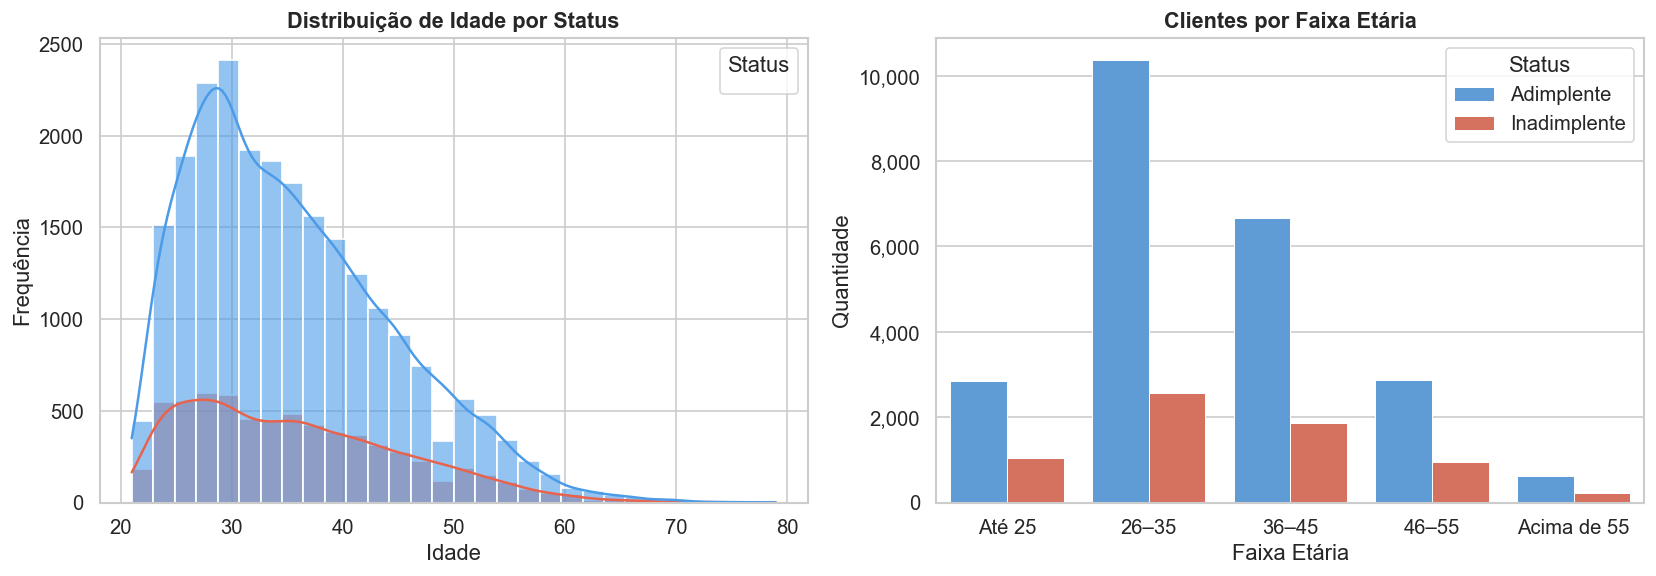

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma + KDE da idade
sns.histplot(data=df, x='idade', hue='inadimplente', kde=True,
             palette=paleta_alvo, bins=30, ax=axes[0], alpha=0.6, edgecolor='white')
axes[0].set_title('Distribuição de Idade por Status')
axes[0].set_xlabel('Idade')
axes[0].set_ylabel('Frequência')
handles0, _ = axes[0].get_legend_handles_labels()
axes[0].legend(handles0, ['Adimplente', 'Inadimplente'], title='Status')

# Countplot por faixa etária
ordem_faixa = ['Até 25', '26–35', '36–45', '46–55', 'Acima de 55']
sns.countplot(data=df, x='faixa_etaria', hue='inadimplente', order=ordem_faixa,
              palette=paleta_alvo, ax=axes[1], edgecolor='white', linewidth=0.6)
axes[1].set_title('Clientes por Faixa Etária')
axes[1].set_xlabel('Faixa Etária')
axes[1].set_ylabel('Quantidade')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
handles1, _ = axes[1].get_legend_handles_labels()
axes[1].legend(handles1, ['Adimplente', 'Inadimplente'], title='Status')

plt.tight_layout()
plt.show()


### 📈 Gráfico 8.2 — Taxa de Utilização do Crédito e Média das Faturas
Comparação da distribuição dessas variáveis derivadas entre clientes adimplentes e inadimplentes.


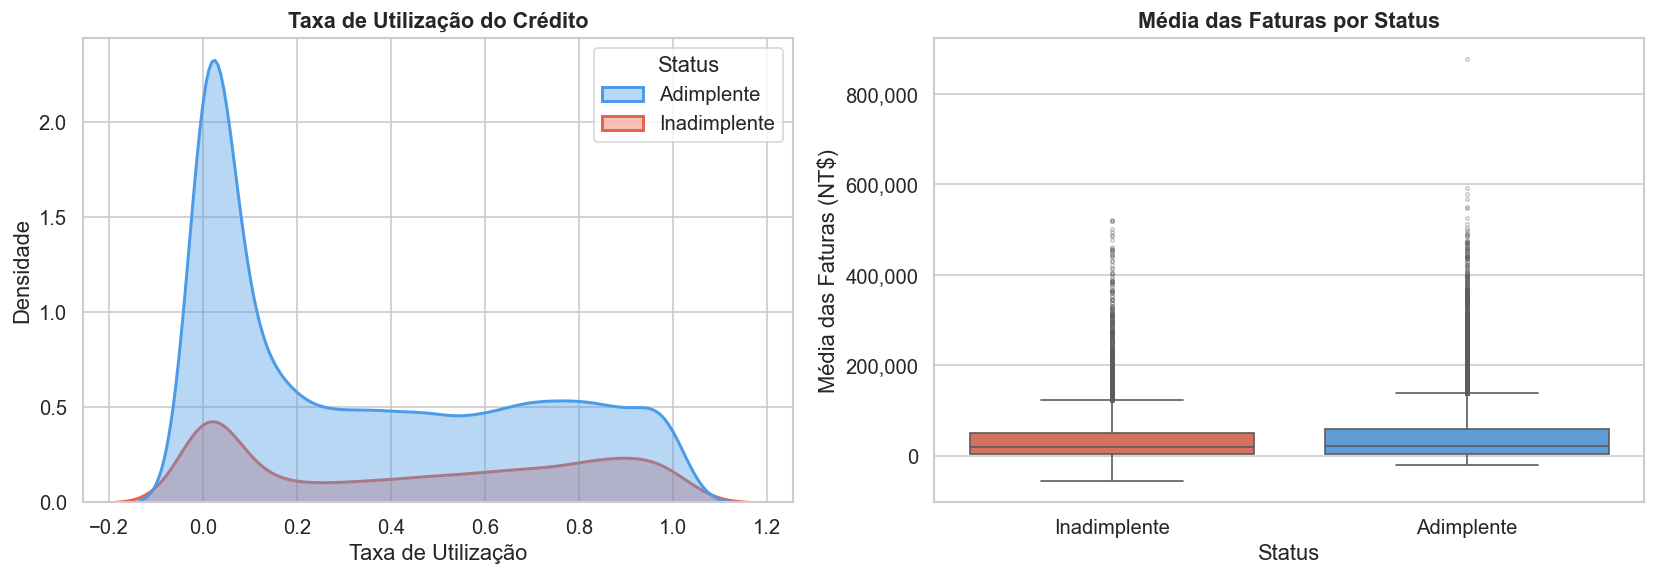

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# KDE: taxa de utilização por status
sns.kdeplot(data=df, x='taxa_utilizacao', hue='inadimplente',
            fill=True, alpha=0.4, palette=paleta_alvo, ax=axes[0], linewidth=1.8)
axes[0].set_title('Taxa de Utilização do Crédito')
axes[0].set_xlabel('Taxa de Utilização')
axes[0].set_ylabel('Densidade')
handles0 = axes[0].legend_.legend_handles
axes[0].legend(handles0, ['Adimplente', 'Inadimplente'], title='Status')

# Boxplot: média da fatura por status
df_alvo = df.copy()
df_alvo['Status'] = df_alvo['inadimplente'].map({0: 'Adimplente', 1: 'Inadimplente'})
sns.boxplot(data=df_alvo, x='Status', y='media_fatura',
            palette={'Adimplente': '#4C9BE8', 'Inadimplente': '#E8634C'},
            ax=axes[1], flierprops=dict(marker='o', markersize=2, alpha=0.3))
axes[1].set_title('Média das Faturas por Status')
axes[1].set_xlabel('Status')
axes[1].set_ylabel('Média das Faturas (NT$)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.show()


### 📈 Gráfico 8.3 — Quantidade de Meses com Atraso no Pagamento
Distribuição do número de meses em atraso, segmentada por inadimplência futura.


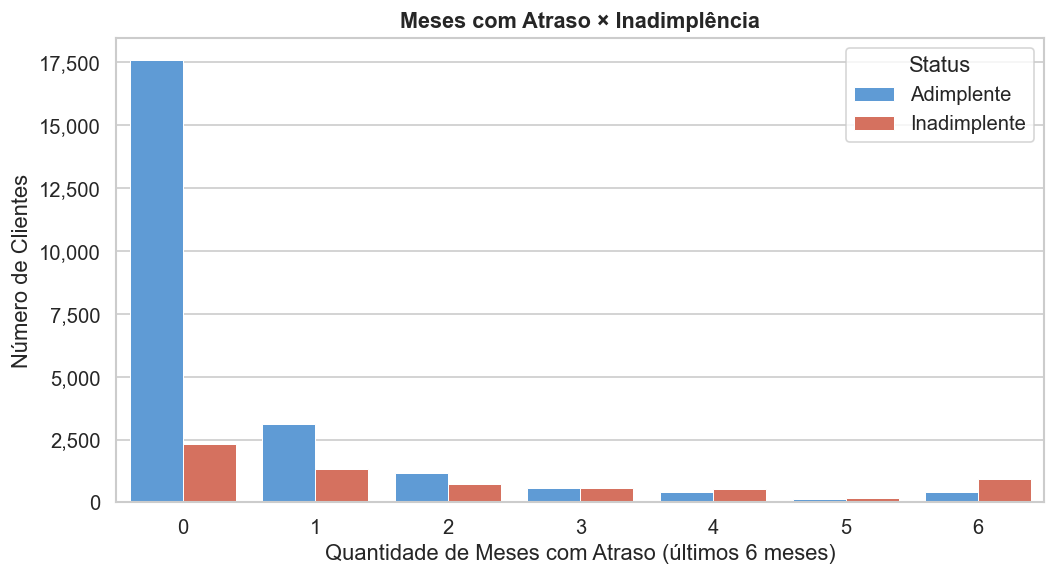

In [27]:
fig, ax = plt.subplots(figsize=(9, 5))

# Frequência relativa por grupo para melhor comparação
atrasos_plot = (
    df.groupby(['qtd_atrasos', 'inadimplente'])
      .size()
      .reset_index(name='contagem')
)
atrasos_plot['Status'] = atrasos_plot['inadimplente'].map({0:'Adimplente', 1:'Inadimplente'})

sns.barplot(data=atrasos_plot, x='qtd_atrasos', y='contagem', hue='Status',
            palette={'Adimplente': '#4C9BE8', 'Inadimplente': '#E8634C'},
            ax=ax, edgecolor='white', linewidth=0.6)

ax.set_title('Meses com Atraso × Inadimplência')
ax.set_xlabel('Quantidade de Meses com Atraso (últimos 6 meses)')
ax.set_ylabel('Número de Clientes')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()


### 📈 Gráfico 8.4 — Perfil de Risco dos Clientes
Taxa de inadimplência dentro de cada categoria de risco criada na engenharia de atributos.


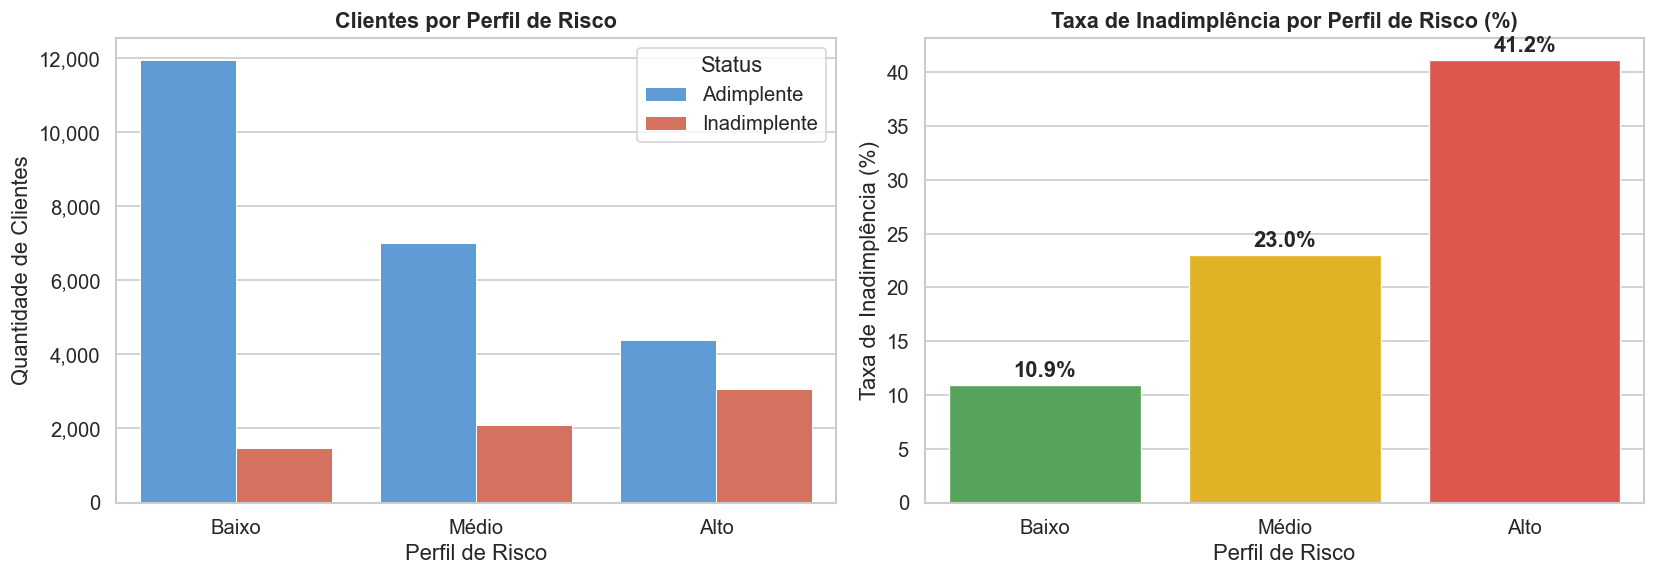

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Countplot de perfil de risco
ordem_risco = ['Baixo', 'Médio', 'Alto']
sns.countplot(data=df, x='perfil_risco', hue='inadimplente', order=ordem_risco,
              palette=paleta_alvo, ax=axes[0], edgecolor='white', linewidth=0.6)
axes[0].set_title('Clientes por Perfil de Risco')
axes[0].set_xlabel('Perfil de Risco')
axes[0].set_ylabel('Quantidade de Clientes')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
handles0, _ = axes[0].get_legend_handles_labels()
axes[0].legend(handles0, ['Adimplente', 'Inadimplente'], title='Status')

# Taxa de inadimplência por perfil de risco (barplot percentual)
taxa_risco = (
    df.groupby('perfil_risco')['inadimplente']
      .mean()
      .reindex(ordem_risco)
      .reset_index()
)
taxa_risco.columns = ['perfil_risco', 'taxa']
taxa_risco['taxa_pct'] = taxa_risco['taxa'] * 100

cores_risco = {'Baixo': '#4CAF50', 'Médio': '#FFC107', 'Alto': '#F44336'}
sns.barplot(data=taxa_risco, x='perfil_risco', y='taxa_pct',
            palette=cores_risco, ax=axes[1], edgecolor='white', linewidth=0.8)
axes[1].set_title('Taxa de Inadimplência por Perfil de Risco (%)')
axes[1].set_xlabel('Perfil de Risco')
axes[1].set_ylabel('Taxa de Inadimplência (%)')
for bar, (_, row) in zip(axes[1].patches, taxa_risco.iterrows()):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.4,
                 f"{row['taxa_pct']:.1f}%",
                 ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()


### 📈 Gráfico 8.5 — Evolução das Faturas e Pagamentos ao Longo dos Meses
Médias mensais de fatura e pagamento, comparando clientes adimplentes e inadimplentes.


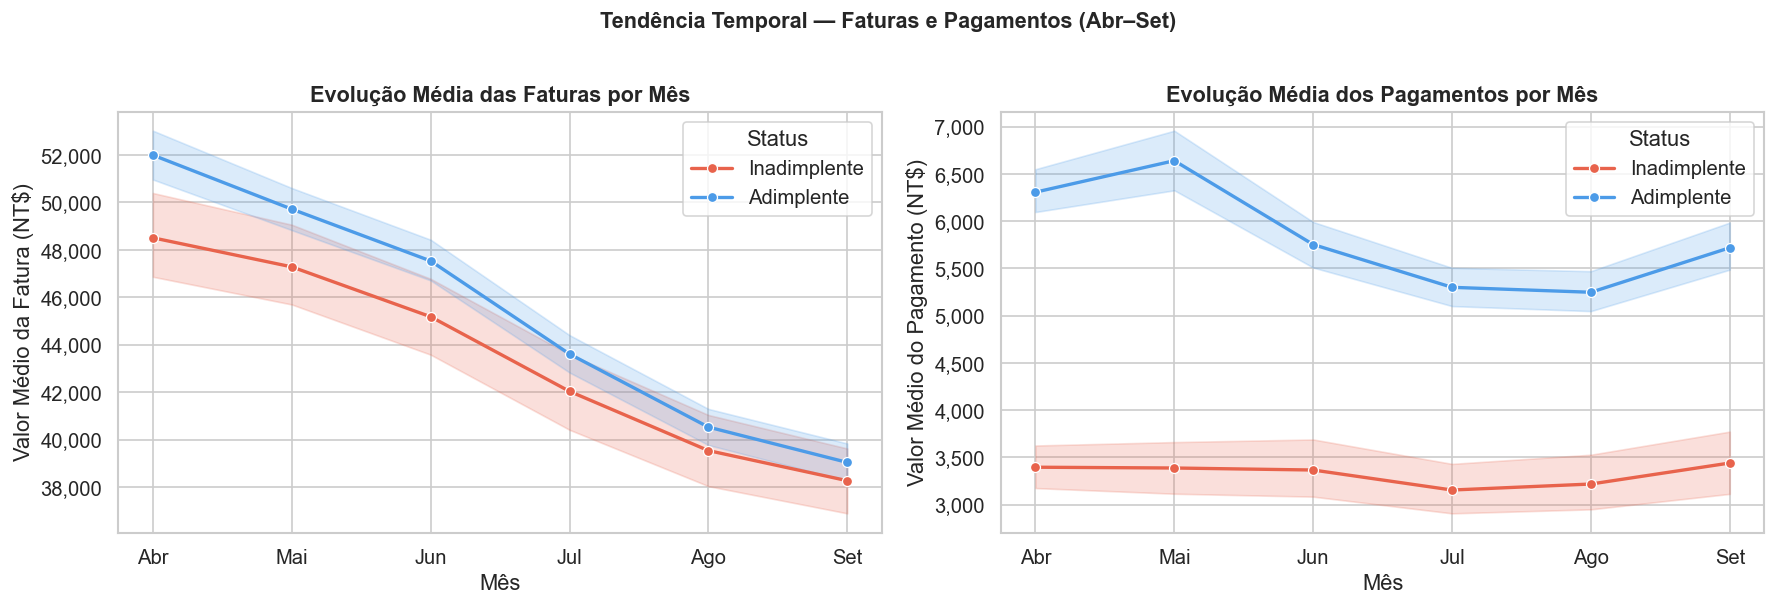

In [29]:
# Reshape para formato longo (long format)
meses = ['Abr', 'Mai', 'Jun', 'Jul', 'Ago', 'Set']

df_fat = df[cols_fatura + ['inadimplente']].copy()
df_fat.columns = meses + ['inadimplente']
df_fat_long = df_fat.melt(id_vars='inadimplente', var_name='Mês', value_name='Fatura')
df_fat_long['Status'] = df_fat_long['inadimplente'].map({0:'Adimplente', 1:'Inadimplente'})

df_pag = df[cols_pagamento + ['inadimplente']].copy()
df_pag.columns = meses + ['inadimplente']
df_pag_long = df_pag.melt(id_vars='inadimplente', var_name='Mês', value_name='Pagamento')
df_pag_long['Status'] = df_pag_long['inadimplente'].map({0:'Adimplente', 1:'Inadimplente'})

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Lineplot: evolução média das faturas
sns.lineplot(data=df_fat_long, x='Mês', y='Fatura', hue='Status',
             palette={'Adimplente':'#4C9BE8','Inadimplente':'#E8634C'},
             estimator='mean', errorbar=('ci', 95), ax=axes[0],
             markers=True, dashes=False, linewidth=2, marker='o')
axes[0].set_title('Evolução Média das Faturas por Mês')
axes[0].set_xlabel('Mês')
axes[0].set_ylabel('Valor Médio da Fatura (NT$)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Lineplot: evolução média dos pagamentos
sns.lineplot(data=df_pag_long, x='Mês', y='Pagamento', hue='Status',
             palette={'Adimplente':'#4C9BE8','Inadimplente':'#E8634C'},
             estimator='mean', errorbar=('ci', 95), ax=axes[1],
             markers=True, dashes=False, linewidth=2, marker='o')
axes[1].set_title('Evolução Média dos Pagamentos por Mês')
axes[1].set_xlabel('Mês')
axes[1].set_ylabel('Valor Médio do Pagamento (NT$)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.suptitle('Tendência Temporal — Faturas e Pagamentos (Abr–Set)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


---
## 9. Verificação Final da Base Tratada
Inspeção completa do dataset após todas as etapas de limpeza e transformação.


In [30]:
print("=" * 55)
print("       RELATÓRIO FINAL DO DATASET TRATADO")
print("=" * 55)
print(f"  Registros  : {df.shape[0]:,}")
print(f"  Variáveis  : {df.shape[1]}")
print(f"  Memória    : {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print("=" * 55)


       RELATÓRIO FINAL DO DATASET TRATADO
  Registros  : 30,000
  Variáveis  : 30
  Memória    : 13.30 MB


In [31]:
nulos_finais = df.isnull().sum()
nulos_finais = nulos_finais[nulos_finais > 0]
if nulos_finais.empty:
    print("Nenhum valor nulo no dataset final.")
else:
    print("Valores nulos restantes:")
    display(nulos_finais)


Nenhum valor nulo no dataset final.


In [32]:
print("Tipos de dados — dataset final:\n")
print(df.dtypes.to_string())


Tipos de dados — dataset final:

limite_credito        int64
sexo                    str
escolaridade            str
estado_civil            str
idade                 int64
status_pag_set        int64
status_pag_ago        int64
status_pag_jul        int64
status_pag_jun        int64
status_pag_mai        int64
status_pag_abr        int64
fatura_set            int64
fatura_ago            int64
fatura_jul            int64
fatura_jun            int64
fatura_mai            int64
fatura_abr            int64
pagamento_set         int64
pagamento_ago         int64
pagamento_jul         int64
pagamento_jun         int64
pagamento_mai         int64
pagamento_abr         int64
inadimplente          int64
media_fatura        float64
media_pagamento     float64
taxa_utilizacao     float64
qtd_atrasos           int64
faixa_etaria       category
perfil_risco            str


In [33]:
print("Primeiras 5 linhas do dataset tratado:\n")
display(df.head())


Primeiras 5 linhas do dataset tratado:



,limite_credito,sexo,escolaridade,estado_civil,idade,status_pag_set,status_pag_ago,status_pag_jul,status_pag_jun,status_pag_mai,status_pag_abr,fatura_set,fatura_ago,fatura_jul,fatura_jun,fatura_mai,fatura_abr,pagamento_set,pagamento_ago,pagamento_jul,pagamento_jun,pagamento_mai,pagamento_abr,inadimplente,media_fatura,media_pagamento,taxa_utilizacao,qtd_atrasos,faixa_etaria,perfil_risco
0,20000,Feminino,Graduação,Casado,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1,1284.00,114.83,0.06,2,Até 25,Médio
1,120000,Feminino,Graduação,Solteiro,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1,2846.17,833.33,0.02,2,26–35,Médio
2,90000,Feminino,Graduação,Solteiro,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0,16942.17,1836.33,0.19,0,26–35,Baixo
3,50000,Feminino,Graduação,Casado,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0,38555.67,1398.00,0.77,0,36–45,Médio
4,50000,Masculino,Graduação,Casado,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0,18223.17,9841.50,0.36,0,Acima de 55,Baixo


### 📈 Gráfico 9.1 — Distribuição da Variável-Alvo e Matriz de Correlação
Balanço das classes e relações lineares entre as variáveis numéricas do dataset final.


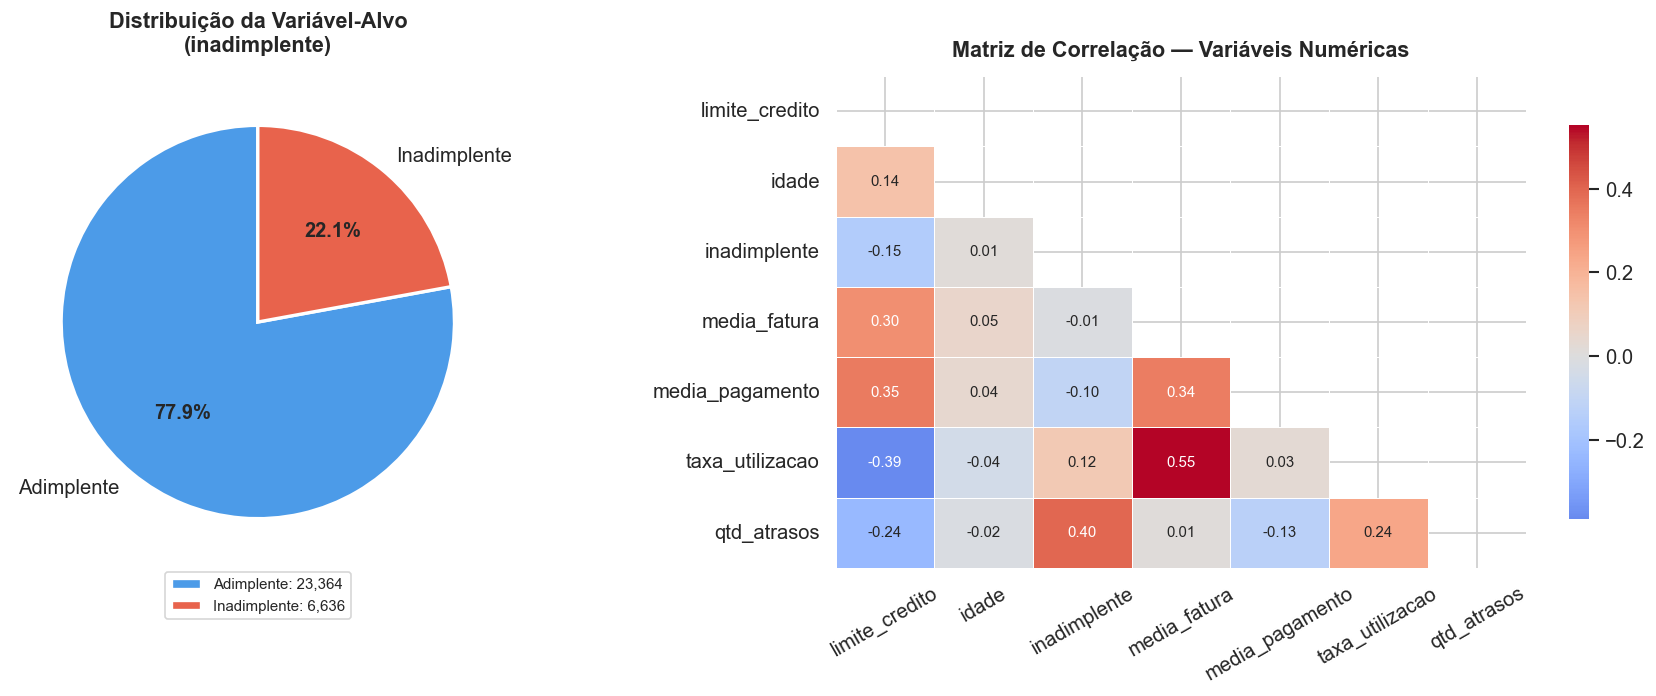

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Pie chart: proporção adimplente × inadimplente ────────────
contagem_alvo = df['inadimplente'].value_counts()
cores_pizza   = ['#4C9BE8', '#E8634C']
wedges, texts, autotexts = axes[0].pie(
    contagem_alvo.values,
    labels=['Adimplente', 'Inadimplente'],
    colors=cores_pizza,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)
for at in autotexts:
    at.set_fontsize(12)
    at.set_fontweight('bold')
axes[0].set_title('Distribuição da Variável-Alvo\n(inadimplente)', pad=15)
axes[0].legend([f'Adimplente: {contagem_alvo[0]:,}',
                f'Inadimplente: {contagem_alvo[1]:,}'],
               loc='lower center', bbox_to_anchor=(0.5, -0.12), fontsize=9)

# ── Heatmap de correlação (variáveis numéricas) ───────────────
cols_num = ['limite_credito', 'idade', 'inadimplente',
            'media_fatura', 'media_pagamento', 'taxa_utilizacao', 'qtd_atrasos']
corr = df[cols_num].corr()

mascara = np.triu(np.ones_like(corr, dtype=bool))  # apenas triângulo inferior
sns.heatmap(corr, mask=mascara, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=axes[1],
            cbar_kws={'shrink': 0.8}, annot_kws={'size': 9})
axes[1].set_title('Matriz de Correlação — Variáveis Numéricas', pad=12)
axes[1].tick_params(axis='x', rotation=30)
axes[1].tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()


### 📈 Gráfico 9.2 — Pairplot das Variáveis Derivadas
Relações par-a-par entre as principais features criadas, segmentadas por inadimplência.


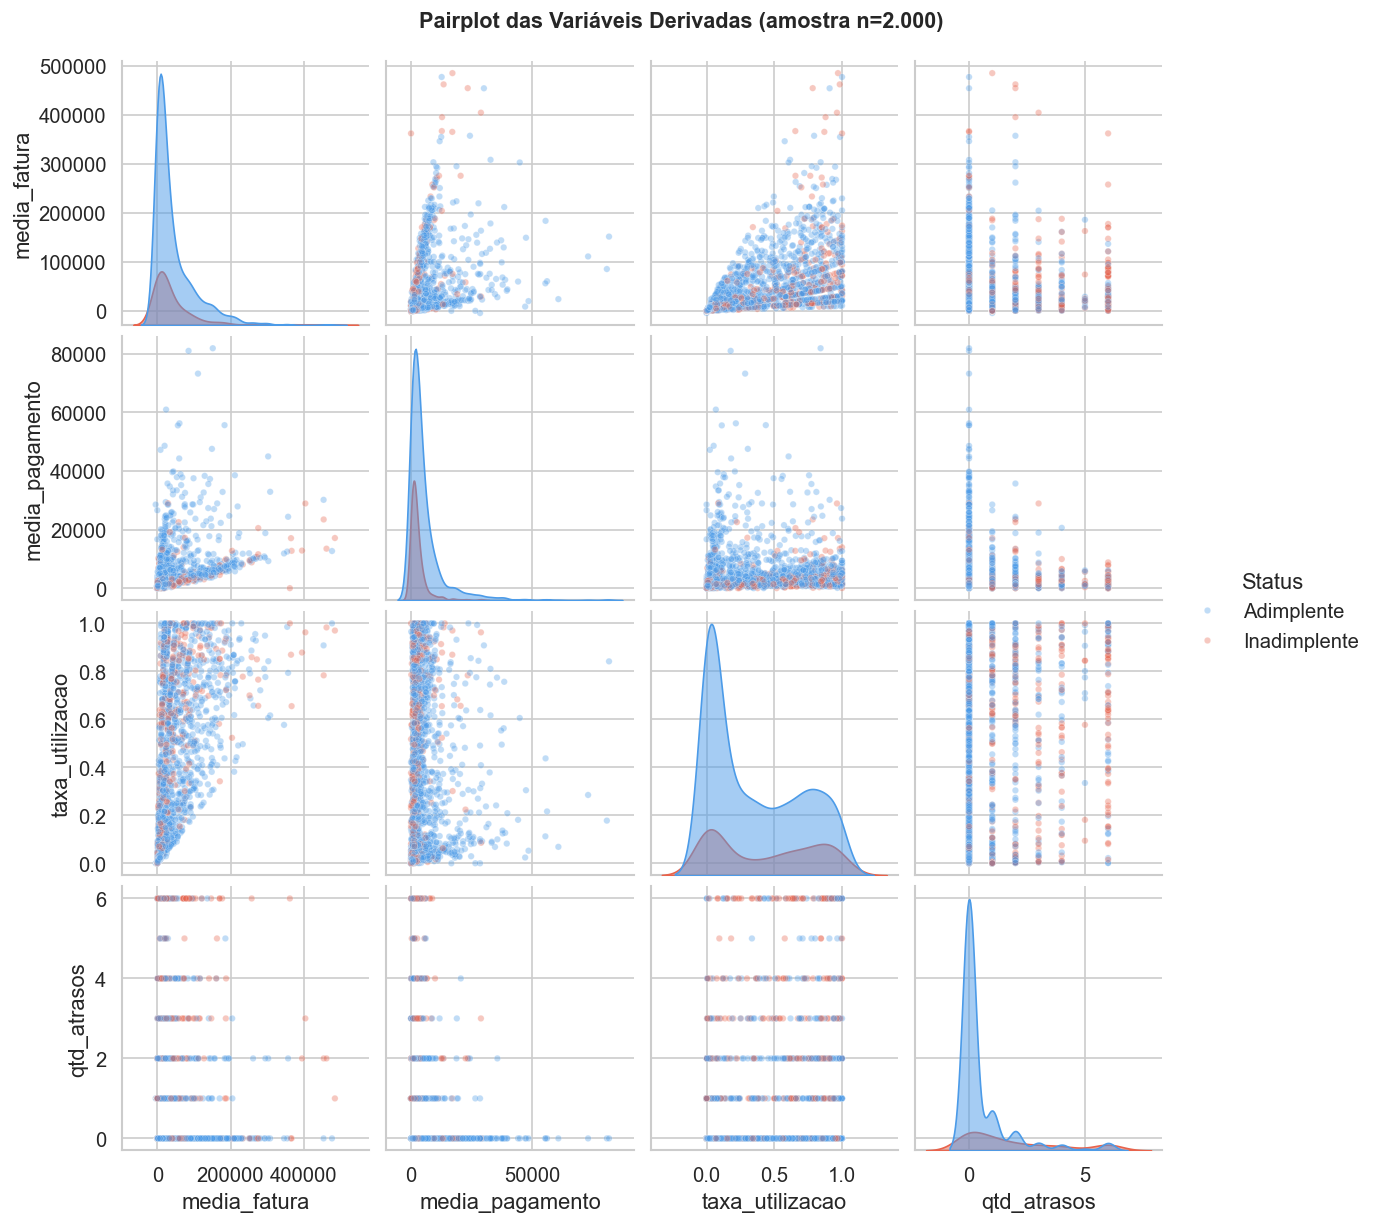

In [35]:
# Pairplot — amostra para desempenho (2.000 registros)
df_sample = df[['media_fatura','media_pagamento','taxa_utilizacao',
                'qtd_atrasos','inadimplente']].sample(2000, random_state=42)
df_sample['Status'] = df_sample['inadimplente'].map({0:'Adimplente', 1:'Inadimplente'})

g = sns.pairplot(
    df_sample.drop(columns='inadimplente'),
    hue='Status',
    palette={'Adimplente':'#4C9BE8', 'Inadimplente':'#E8634C'},
    diag_kind='kde',
    plot_kws={'alpha': 0.35, 's': 15},
    diag_kws={'fill': True, 'alpha': 0.5}
)
g.figure.suptitle('Pairplot das Variáveis Derivadas (amostra n=2.000)',
                  y=1.02, fontsize=13, fontweight='bold')
plt.show()


---
## 10. Exportação da Base Tratada
Salvamento do dataset limpo e enriquecido em formato CSV.


In [36]:
import os

ARQUIVO_SAIDA = 'data/credit_card_default_tratado.csv'
df.to_csv(ARQUIVO_SAIDA, index=False, encoding='utf-8-sig')

tamanho_kb = os.path.getsize(ARQUIVO_SAIDA) / 1024

print(f"Dataset exportado com sucesso!")
print(f" Arquivo  : {ARQUIVO_SAIDA}")
print(f" Tamanho  : {tamanho_kb:.1f} KB")
print(f" Registros: {len(df):,}")
print(f" Colunas  : {df.shape[1]}")


Dataset exportado com sucesso!
 Arquivo  : data/credit_card_default_tratado.csv
 Tamanho  : 4540.4 KB
 Registros: 30,000
 Colunas  : 30


---
## ✅ Conclusão

O pipeline completo de tratamento, preparação e visualização de dados foi concluído com êxito.

| # | Etapa | Resultado |
|---|-------|-----------|
| 1 | Importação de bibliotecas | Pandas, NumPy, Seaborn e Matplotlib carregados |
| 2 | Carregamento do dataset | 30.000 registros, 25 colunas originais |
| 3 | Visualização inicial | Estrutura compreendida |
| 4 | Verificação da estrutura | Heatmap de nulos gerado |
| 5 | Renomeação das colunas | Nomes em português padronizados |
| 6 | Tratamento de dados | Nulos, duplicatas e categorias inconsistentes tratados |
| 7 | Variáveis categóricas | SEX, EDUCATION e MARRIAGE rotulados e visualizados |
| 8 | Engenharia de atributos | 6 novas features + 5 gráficos de análise |
| 9 | Verificação final | Matriz de correlação e pairplot gerados |
| 10 | Exportação | `credit_card_default_tratado.csv` gerado |

### 📊 Gráficos produzidos com Seaborn

| # | Gráfico | Tipo |
|---|---------|------|
| 4.1 | Mapa de valores ausentes | Heatmap |
| 6.1 | Categorias antes do mapeamento | Barplot |
| 7.1 | Variáveis categóricas × inadimplência | Countplot |
| 7.2 | Limite de crédito por escolaridade e sexo | Boxplot + Violinplot |
| 8.1 | Distribuição de idade e faixa etária | Histplot + Countplot |
| 8.2 | Taxa de utilização e média de faturas | KDEplot + Boxplot |
| 8.3 | Meses com atraso × inadimplência | Barplot |
| 8.4 | Perfil de risco dos clientes | Countplot + Barplot |
| 8.5 | Evolução mensal de faturas e pagamentos | Lineplot |
| 9.1 | Variável-alvo e matriz de correlação | Pie + Heatmap |
| 9.2 | Relações entre features derivadas | Pairplot |

